In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from rwmcmc.targets import gaussian_1d_log_pdf
from rwmcmc.samplers import random_walk_metropolis_hastings_1d

In [ ]:
step_sizes = [0.1, 0.5, 1.0, 2.5, 10.0]
n_samples = 10_000
results = {}

print(f"{'step_size':>10}  {'acceptance':>10}  {'mean':>8}  {'std':>8}")
print("-" * 44)

for s in step_sizes:
    rng = np.random.default_rng(seed=42) # Now, we do what I mentioned in the samples.py. We set the same seed for every run of the code for the sake of comparison.
    samples, accepted = random_walk_metropolis_hastings_1d(
        target_log_pdf=gaussian_1d_log_pdf,
        x0=0.0,
        n_samples=n_samples,
        step_size=s,
        rng=rng,
    )
    results[s] = {
        "samples": samples,
        "accepted": accepted,
        "acceptance_rate": accepted.mean(),
    }
    print(f"{s:>10.1f}  {accepted.mean():>10.3f}  {samples.mean():>8.4f}  {samples.std():>8.4f}")

 step_size  acceptance      mean       std
--------------------------------------------
       0.1       0.968   -0.1359    1.0799
       0.5       0.843   -0.0738    1.0252
       1.0       0.706   -0.0372    1.0092
       2.5       0.426   -0.0097    1.0067
      10.0       0.121   -0.0108    0.9541


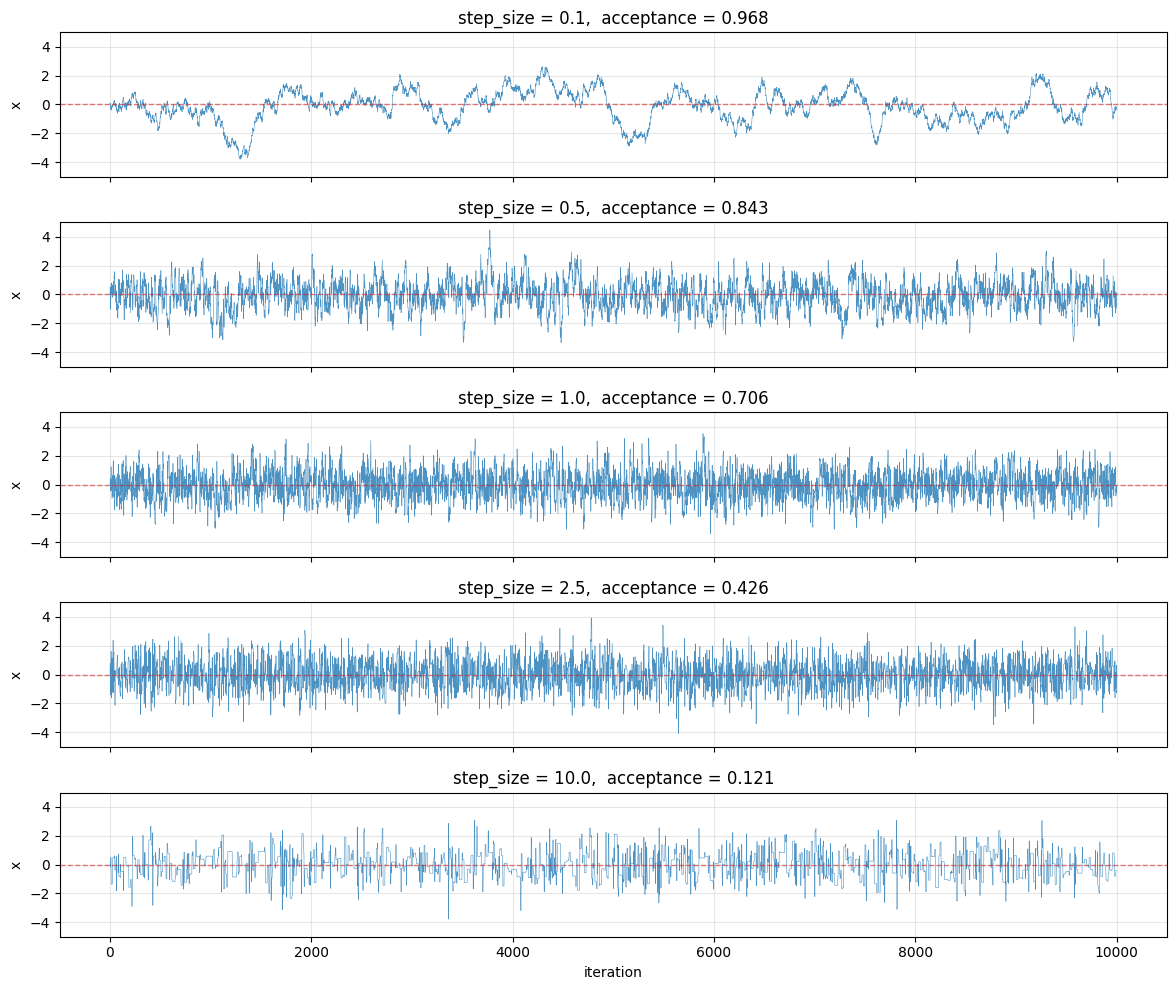

In [6]:
fig, axes = plt.subplots(len(step_sizes), 1, figsize=(12, 2 * len(step_sizes)), sharex=True)

for ax, s in zip(axes, step_sizes):
    samples = results[s]["samples"]
    acc = results[s]["acceptance_rate"]

    ax.plot(samples, linewidth=0.4, alpha=0.8)
    ax.axhline(0, color="C3", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_ylabel("x")
    ax.set_title(f"step_size = {s},  acceptance = {acc:.3f}")
    ax.set_ylim(-5, 5)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("iteration")
plt.tight_layout()
plt.show()

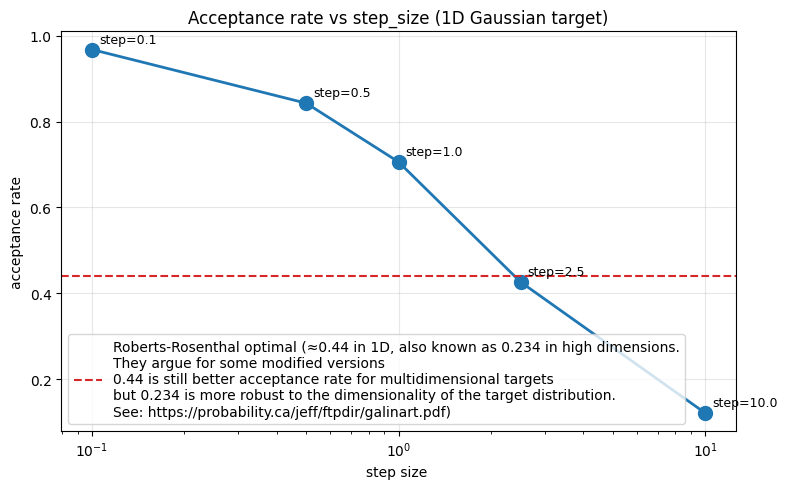

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

acc_rates = [results[s]["acceptance_rate"] for s in step_sizes]
ax.plot(step_sizes, acc_rates, "o-", color="C0", markersize=10, linewidth=2)
ax.axhline(0.44, color="C3", linestyle="--", linewidth=1.5,
           label="Roberts-Rosenthal optimal (~0.44 in 1D, also known as 0.234 in high dimensions.\nThey argue for some modified versions\n0.44 is still better acceptance rate for multidimensional targets\nbut 0.234 is more robust to the dimensionality of the target distribution.\nSee: https://probability.ca/jeff/ftpdir/galinart.pdf)")

# Annotate each point
for s, acc in zip(step_sizes, acc_rates):
    ax.annotate(f"step={s}", xy=(s, acc), xytext=(5, 5),
                textcoords="offset points", fontsize=9)

ax.set_xlabel("step size ")
ax.set_ylabel("acceptance rate")
ax.set_xscale("log")
ax.set_title("Acceptance rate vs step_size (1D Gaussian target)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()